# Lecture 3 — Probability Review + Bayesian Decision Theory

### Main topics
- Bayes' rule: prior, likelihood, evidence, posterior
- Bayes minimum-error decision rule (Gaussian and non-Gaussian examples)
- How class priors move the decision boundary
- Loss and conditional risk
- Gaussian classifiers: shared covariance → linear boundary, different covariance → quadratic boundary
- Real problem: breast-cancer diagnosis with posterior, priors and risk

In [ ]:
# Core packages used throughout the lecture
import numpy as np
import matplotlib.pyplot as plt

# scipy.stats.norm and multivariate_normal are used to generate multivariate Gaussian samples
from scipy.stats import norm, multivariate_normal

#Linear Discriminant Analysis (LDA) and Quadratic Discriminant Analysis (QDA) are used to fit the Bayes classifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)

# Reproducible random-number generator
rng = np.random.default_rng(42)

# Consistent plotting style: one color per class everywhere in the notebook
#rcParams are global settings for matplotlib, and we update them to set the font size, enable grid lines, and adjust the transparency of the grid lines.
#  We also define two colors for the two classes in our classification problem.
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
COL1, COL2 = "tab:blue", "tab:orange"   # class 1 / class 0  and  class 2 / class 1

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# Helpers used by the LDA / QDA sections
def draw_class_shape(ax, Xc, color, label=None):
    """Sample mean (x) and 1-, 2-sigma covariance ellipses of one class."""
    # Xc is a 2D array of shape (n_samples, n_features) representing the data points of one class. 
    # The function calculates the mean and covariance of the class, and then draws ellipses representing the 1-sigma and 2-sigma contours of the class distribution on the provided axis (ax). The color parameter specifies the color of the ellipses, and an optional label can be provided for the legend.
    
    #np.cov(Xc.T) computes the covariance matrix of the class data points.
    
    m, S = Xc.mean(axis=0), np.cov(Xc.T)

    # np.linalg.cholesky(S) performs a Cholesky decomposition of the covariance matrix to obtain a lower triangular matrix L. This matrix is used to transform a unit circle into an ellipse that represents the covariance structure of the class.
    # S = L @ L.T.
    L = np.linalg.cholesky(S)
    t = np.linspace(0, 2 * np.pi, 200)
    circ = np.stack([np.cos(t), np.sin(t)])
    for k, r in enumerate([1, 2]):
        e = m[:, None] + r * L @ circ
        ax.plot(e[0], e[1], color=color, linewidth=1.3,
                label=label if k == 0 else None)
    ax.scatter(*m, marker="x", s=120, color="k", zorder=4)



m = [3.17 2.12]
S =
 [[3.88 1.96]
 [1.96 2.87]]
L =
 [[1.97 0.  ]
 [0.99 1.37]]
L @ L.T =
 [[3.88 1.96]
 [1.96 2.87]]


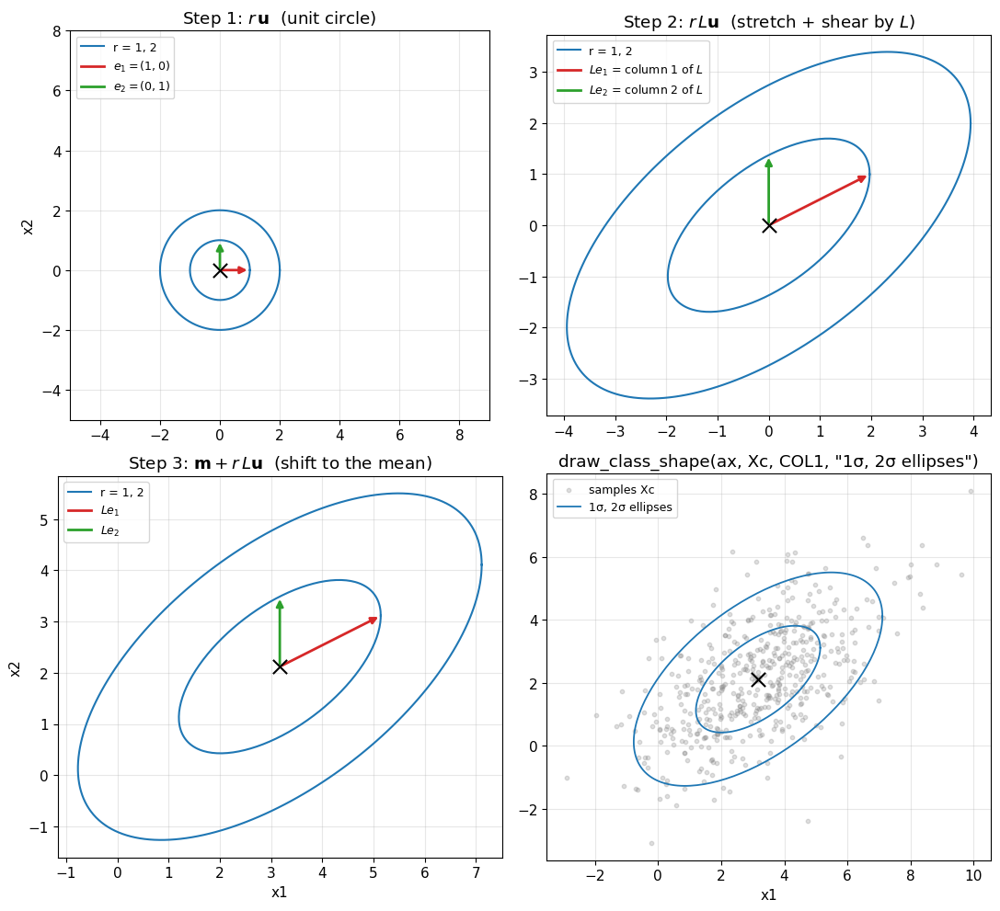

In [ ]:
# Demo: what draw_class_shape does, step by step, on one toy class.
# A separate generator, so the shared `rng` (and every later cell) is unchanged.
rng_demo = np.random.default_rng(0)
Xc = rng_demo.multivariate_normal([3.0, 2.0], [[4.0, 2.0], [2.0, 3.0]], size=500)

# The first lines of draw_class_shape
m, S = Xc.mean(axis=0), np.cov(Xc.T)       # m: (2,),  S: (2, 2)
L = np.linalg.cholesky(S)                  # lower triangular, S = L @ L.T
t = np.linspace(0, 2 * np.pi, 200)
circ = np.stack([np.cos(t), np.sin(t)])    # unit circle, shape (2, 200)

print("m =", m.round(2))
print("S =\n", S.round(2))
print("L =\n", L.round(2))
print("L @ L.T =\n", (L @ L.T).round(2))

# Steps 1-3 build  e = m + r * L @ circ  one operation at a time;
# the arrows show where e1 = (1, 0) and e2 = (0, 1) go (the columns of the matrix).
origin, I = np.zeros(2), np.eye(2)
steps = [
    (r"Step 1: $r\,\mathbf{u}$  (unit circle)", I, origin,
     [r"$e_1 = (1, 0)$", r"$e_2 = (0, 1)$"]),
    (r"Step 2: $r\,L\mathbf{u}$  (stretch + shear by $L$)", L, origin,
     [r"$L e_1$ = column 1 of $L$", r"$L e_2$ = column 2 of $L$"]),
    (r"Step 3: $\mathbf{m} + r\,L\mathbf{u}$  (shift to the mean)", L, m,
     [r"$L e_1$", r"$L e_2$"]),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
# axes = [[axes[0, 0], axes[0, 1]],
#          [axes[1, 0], axes[1, 1]]]
# axes.flat = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]
for ax, (title, A, c, arrow_names) in zip(axes.flat, steps):
    for r in [1, 2]:
        e = c[:, None] + r * A @ circ
        ax.plot(e[0], e[1], color=COL1, linewidth=1.5,
                label="r = 1, 2" if r == 1 else None)
    for j, col in enumerate(["tab:red", "tab:green"]):
        ax.annotate("", xy=c + A[:, j], xytext=c,
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2))
        ax.plot([], [], color=col, lw=2, label=arrow_names[j])
    ax.scatter(*c, marker="x", s=120, color="k", zorder=4)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)

# Step 4: the helper itself, on the data
ax = axes[1, 1]
ax.scatter(Xc[:, 0], Xc[:, 1], alpha=0.25, color="gray", s=10, label="samples Xc")
draw_class_shape(ax, Xc, COL1, "1σ, 2σ ellipses")
ax.set_title('draw_class_shape(ax, Xc, COL1, "1σ, 2σ ellipses")')
ax.legend(loc="upper left", fontsize=9)

for ax in axes.flat:
    ax.set_aspect("equal")
for ax in axes[1]:
    ax.set_xlabel("x1")
for ax in axes[:, 0]:
    ax.set_ylabel("x2")
axes[0, 0].set_xlim(-5, 9)
axes[0, 0].set_ylim(-5, 8)
plt.tight_layout()
plt.show()

In [ ]:
def plot_boundary(model, X0, X1, ax, title, show_shape=True):
    # X0，X1 two shape (n_samples, n_features=2)
    #np.vstack([X0, X1]) vertically stacks the two arrays X0 and X1
    #np.vstack will not create new demension, np.stack will create new demension.
    Xall = np.vstack([X0, X1])
    # xx1: x1 (horizontal) coordinate of every grid point, shape (300, 300)
    # xx2: x2 (vertical) coordinate of every grid point, shape (300, 300)
    # grid point (i, j) = (xx1[i, j], xx2[i, j])
    xx1, xx2 = np.meshgrid(
        np.linspace(Xall[:, 0].min() - 1, Xall[:, 0].max() + 1, 300),
        np.linspace(Xall[:, 1].min() - 1, Xall[:, 1].max() + 1, 300),
    )
    #ravel() flattens the 2D arrays xx1 and xx2 into 1D arrays.
    #np.c_ combines them column-wise to create a 2D array of grid points. Each row of grid_points represents a point in the feature space where we want to evaluate the decision function of the model.
    grid_points = np.c_[xx1.ravel(), xx2.ravel()]
    # grid_points shape (300*300, 2) = (90000, 2)
    # decision_function = log P(class 1 | x) - log P(class 0 | x); zero level = boundary
    score = model.decision_function(grid_points).reshape(xx1.shape)

    # Fill each grid point by its predicted class Z = (score > 0), which is 0 or 1.
    # levels = band edges: [-0.5, 0.5, 1.5] -> 2 bands, one around 0, one around 1
    # cmap   = one color per band, in order: Z = 0 -> COL1, Z = 1 -> COL2
    # (see the levels / cmap demo below); alpha = transparency
    ax.contourf(xx1, xx2, (score > 0).astype(int), levels=[-0.5, 0.5, 1.5],
                cmap=ListedColormap([COL1, COL2]), alpha=0.15)

    # Boundary: the curve where score = 0, i.e. P(class 1 | x) = P(class 0 | x).
    # contour interpolates between grid points, so the curve is smooth.
    ax.contour(xx1, xx2, score, levels=[0], colors="k", linewidths=2)
    # contour lines never show up in the legend, so draw an empty line with the
    # same style; it is invisible and only serves as the legend entry.
    ax.plot([], [], color="k", linewidth=2, label="Bayes boundary (fitted)")

    # Samples; alpha < 1 so that dense regions look darker
    ax.scatter(X0[:, 0], X0[:, 1], alpha=0.3, color=COL1, s=12, label="Class 0")
    ax.scatter(X1[:, 0], X1[:, 1], alpha=0.3, color=COL2, s=12, label="Class 1")
    # Mean and 1σ, 2σ ellipses of each class (labelled once -> one legend entry)
    if show_shape:
        draw_class_shape(ax, X0, COL1, "1σ, 2σ ellipses")
        draw_class_shape(ax, X1, COL2)

    # Show exactly the grid, so the colored background fills the whole plot
    ax.set_xlim(xx1.min(), xx1.max())
    ax.set_ylim(xx2.min(), xx2.max())
    # Same scale on both axes: circles stay circles and angles stay correct
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)

### How `plot_boundary` works

`plot_boundary(model, X0, X1, ax, title)` takes a **fitted** two-class sklearn model and the samples of class 0 and class 1. It

1. builds a 300 × 300 grid over the data and evaluates `score = model.decision_function(grid)` $= \ln P(1\mid\mathbf{x}) - \ln P(0\mid\mathbf{x})$ at every grid point;
2. colors the grid by the sign of the score (score > 0 → class 1) and draws the zero level, score = 0, which is the decision boundary;
3. adds the samples and calls `draw_class_shape` for both classes.

The next cell runs these steps on a toy example with QDA (Section 9). Later sections only call `plot_boundary`.

x_test = [1. 4.]
P(class 0 | x) = 0.845,   P(class 1 | x) = 0.155
score = log(P1 / P0) = -1.694   ->   predicted class 0


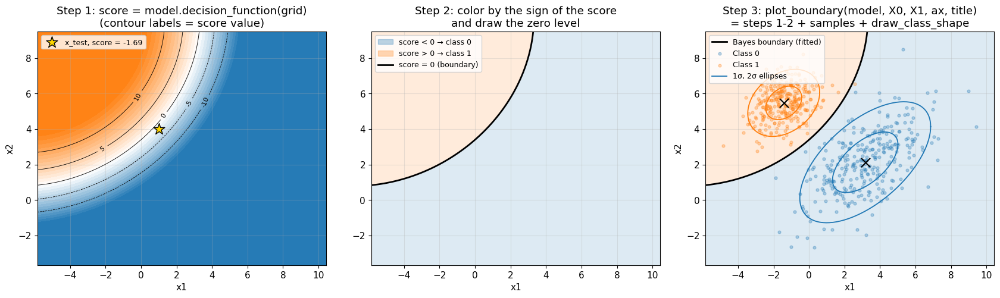

In [ ]:
# Demo: what plot_boundary does, step by step, on two toy classes.
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# A separate generator, so the shared `rng` (and every later cell) is unchanged.
rng_demo = np.random.default_rng(1)
X0_demo = rng_demo.multivariate_normal([3.0, 2.0], [[4.0, 2.0], [2.0, 3.0]], size=300)
X1_demo = rng_demo.multivariate_normal([-1.5, 5.5], [[1.0, 0.3], [0.3, 0.8]], size=300)
X_demo = np.vstack([X0_demo, X1_demo])
# Labels in the same order as X_demo: 300 zeros (class 0), then 300 ones (class 1);
# np.r_ joins the two arrays end to end -> shape (600,)
y_demo = np.r_[np.zeros(len(X0_demo), dtype=int), np.ones(len(X1_demo), dtype=int)]

# Any fitted two-class model with decision_function works; QDA is Section 9.
model_demo = QuadraticDiscriminantAnalysis().fit(X_demo, y_demo)

# One test point (the star in Step 1): its score and the class it is assigned to
x_test = np.array([[1.0, 4.0]])
p0, p1 = model_demo.predict_proba(x_test)[0]
s_test = model_demo.decision_function(x_test)[0]     # = log(p1 / p0)
print(f"x_test = {x_test[0]}")
print(f"P(class 0 | x) = {p0:.3f},   P(class 1 | x) = {p1:.3f}")
print(f"score = log(P1 / P0) = {s_test:.3f}   ->   predicted class {int(s_test > 0)}")

# Step 1: the grid plot_boundary builds, and the score at every grid point
xx1, xx2 = np.meshgrid(
    np.linspace(X_demo[:, 0].min() - 1, X_demo[:, 0].max() + 1, 300),
    np.linspace(X_demo[:, 1].min() - 1, X_demo[:, 1].max() + 1, 300),
)
grid_points = np.c_[xx1.ravel(), xx2.ravel()]      # (90000, 2)
score = model_demo.decision_function(grid_points).reshape(xx1.shape)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.6))

ax = axes[0]
cmap_score = LinearSegmentedColormap.from_list("score", [COL1, "white", COL2])
ax.contourf(xx1, xx2, np.clip(score, -15, 15), levels=30,   # clipped for display only
            cmap=cmap_score, norm=TwoSlopeNorm(vcenter=0))
cs = ax.contour(xx1, xx2, score, levels=[-10, -5, 0, 5, 10], colors="k", linewidths=0.6)
ax.clabel(cs, fmt="%d", fontsize=8)
ax.scatter(*x_test[0], marker="*", s=200, color="gold", edgecolor="k", zorder=4,
           label=f"x_test, score = {s_test:.2f}")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Step 1: score = model.decision_function(grid)\n"
             "(contour labels = score value)")

# Step 2: sign of the score -> regions, zero level -> boundary
ax = axes[1]
ax.contourf(xx1, xx2, (score > 0).astype(int), levels=[-0.5, 0.5, 1.5],
            cmap=ListedColormap([COL1, COL2]), alpha=0.15)
ax.contour(xx1, xx2, score, levels=[0], colors="k", linewidths=2)
ax.legend(handles=[
    Patch(color=COL1, alpha=0.3, label="score < 0 → class 0"),
    Patch(color=COL2, alpha=0.3, label="score > 0 → class 1"),
    Line2D([], [], color="k", lw=2, label="score = 0 (boundary)"),
], loc="upper left", fontsize=9)
ax.set_title("Step 2: color by the sign of the score\n"
             "and draw the zero level")

for ax in axes[:2]:
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
axes[0].set_ylabel("x2")

# Step 3: the helper itself does steps 1-2 and adds the samples and ellipses
plot_boundary(model_demo, X0_demo, X1_demo, axes[2],
              "Step 3: plot_boundary(model, X0, X1, ax, title)\n"
              "= steps 1-2 + samples + draw_class_shape")

plt.tight_layout()
plt.show()

#### What `levels` and `cmap` do in `contourf`

`ax.contourf(xx1, xx2, Z, levels=..., cmap=...)` colors the plane in **bands** of the value `Z`:

- **`levels` = the band edges.** $n$ levels make $n-1$ bands, and each grid point goes into the band whose edges enclose its `Z`. The colorbar in the cell below draws these bands.
- **`cmap` = the colors**, one per band, in order.

In `plot_boundary`, `Z = (score > 0)` is only 0 or 1:

| band (between two levels) | grid points in it | color from `ListedColormap([COL1, COL2])` |
|---|---|---|
| −0.5 to 0.5 | Z = 0 → class 0 | COL1 (blue) |
| 0.5 to 1.5 | Z = 1 → class 1 | COL2 (orange) |

The edges sit halfway between 0 and 1, so each value lands in the middle of its own band. The cell below compares this with two other choices.

In [ ]:
# How levels and cmap turn the 0/1 labels into colors
# (uses xx1, xx2 and score from the cell above)
Z = (score > 0).astype(int)        # 0 = class 0, 1 = class 1

cases = [
    # title, levels, cmap
    ("What plot_boundary uses:\nlevels=[-0.5, 0.5, 1.5], ListedColormap([COL1, COL2])",
     [-0.5, 0.5, 1.5], ListedColormap([COL1, COL2])),
    ("levels=[0, 1, 2]: 0 and 1 land in the SAME band\n(band 2 is empty) -> one color",
     [0, 1, 2], ListedColormap([COL1, COL2])),
    ("Same levels, cmap=\"viridis\":\nsame two bands, different colors",
     [-0.5, 0.5, 1.5], "viridis"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
for ax, (title, levels, cmap) in zip(axes, cases):
    cf = ax.contourf(xx1, xx2, Z, levels=levels, cmap=cmap)
    # The colorbar shows the bands: edges at the levels, one color per band
    fig.colorbar(cf, ax=ax, shrink=0.8, ticks=levels, label="levels = band edges")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x1")
axes[0].set_ylabel("x2")
plt.tight_layout()
plt.show()

## 1. Probability review and Bayes' rule

Conditional probability:

$$P(A\mid B)=\frac{P(A\cap B)}{P(B)}.$$

Bayes' rule:

$$P(\omega_i\mid x)=\frac{p(x\mid \omega_i)P(\omega_i)}{p(x)},\qquad
p(x)=\sum_j p(x\mid\omega_j)P(\omega_j).$$

- $P(\omega_i)$: **prior**
- $p(x\mid\omega_i)$: **likelihood / class-conditional density**
- $p(x)$: **evidence**
- $P(\omega_i\mid x)$: **posterior**

In [3]:
# A compact numerical Bayes-rule example:
#
# w1 = normal machine
# w2 = faulty machine
# x  = alarm is observed

P_w1 = 0.80
P_w2 = 0.20

P_alarm_given_w1 = 0.10
P_alarm_given_w2 = 0.85

# Evidence:
P_alarm = (
    P_alarm_given_w1 * P_w1
    + P_alarm_given_w2 * P_w2
)

# Posterior:
P_w2_given_alarm = (
    P_alarm_given_w2 * P_w2 / P_alarm
)

print("Prior P(fault)            =", P_w2)
print("P(alarm | fault)          =", P_alarm_given_w2)
print("Evidence P(alarm)         =", round(P_alarm, 3))
print("Posterior P(fault|alarm)  =", round(P_w2_given_alarm, 3))


Prior P(fault)            = 0.2
P(alarm | fault)          = 0.85
Evidence P(alarm)         = 0.25
Posterior P(fault|alarm)  = 0.68


## 2. Gaussian class-conditional densities

A common Bayesian classifier assumes that each class has a Gaussian density.

For one feature,

$$p(x\mid\omega_i)
=
\frac{1}{\sqrt{2\pi\sigma_i^2}}
\exp\left[
-\frac{(x-\mu_i)^2}{2\sigma_i^2}
\right].$$

The class with the largest posterior is selected under minimum classification error.

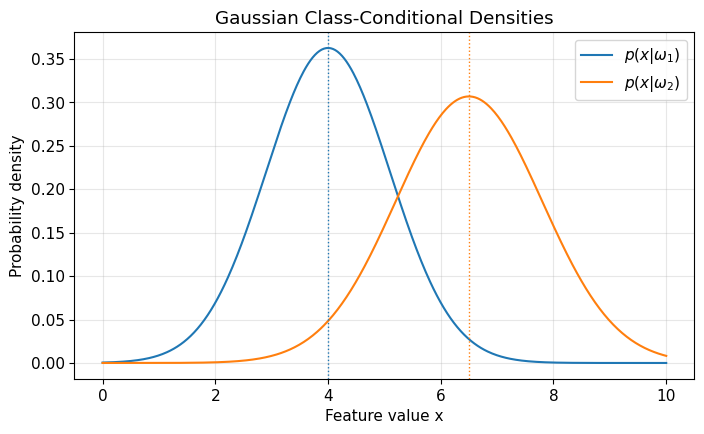

In [ ]:
# Two 1-D Gaussian class-conditional distributions

from scipy.stats import norm, multivariate_normal

x = np.linspace(0, 10, 500)

mu_1, sigma_1 = 4.0, 1.1
mu_2, sigma_2 = 6.5, 1.3

p_x_given_w1 = norm.pdf(x, loc=mu_1, scale=sigma_1)
p_x_given_w2 = norm.pdf(x, loc=mu_2, scale=sigma_2)

plt.figure(figsize=(8, 4.5))
plt.plot(x, p_x_given_w1, color=COL1, label=r"$p(x|\omega_1)$")
plt.plot(x, p_x_given_w2, color=COL2, label=r"$p(x|\omega_2)$")
plt.axvline(mu_1, color=COL1, linestyle=":", linewidth=1)
plt.axvline(mu_2, color=COL2, linestyle=":", linewidth=1)
plt.xlabel("Feature value x")
plt.ylabel("Probability density")
plt.title("Gaussian Class-Conditional Densities")
plt.legend()
plt.show()


### From likelihood to posterior

The likelihood alone is not enough when the priors are unequal.

We compute

$$P(\omega_i\mid x)
=
\frac{p(x\mid\omega_i)P(\omega_i)}
{\sum_j p(x\mid\omega_j)P(\omega_j)}.$$


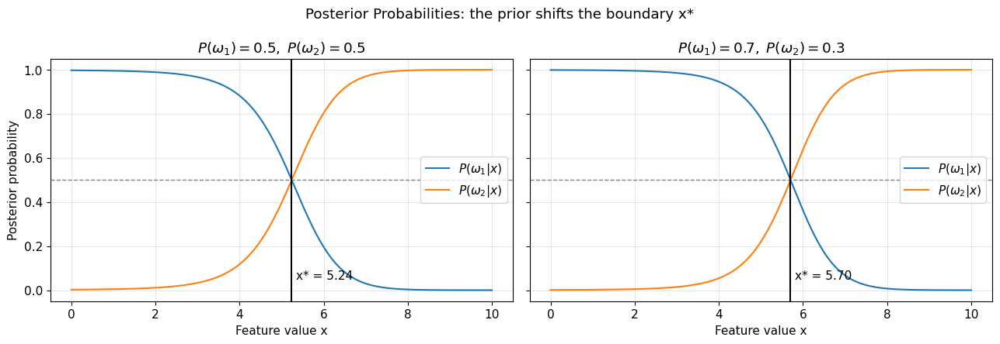

In [ ]:
# Compare equal vs unequal priors

def posteriors(prior_1, prior_2):
    evidence = p_x_given_w1 * prior_1 + p_x_given_w2 * prior_2
    return (p_x_given_w1 * prior_1 / evidence,
            p_x_given_w2 * prior_2 / evidence)

# The Bayes boundary x* is where the two posterior curves cross.
def crossing(x, a, b):
    """x-locations where curve a crosses curve b."""
    # np.sign: the sign of every entry, e.g. np.sign([2, -1, 0]) -> [1, -1, 0].
    # s[i] = +1 where curve a is above b, -1 where it is below.
    s = np.sign(a - b)
    # np.diff: differences of neighbours, d[i] = s[i+1] - s[i], e.g. [1, 1, -1] -> [0, -2].
    # d[i] != 0 means the sign flips between x[i] and x[i+1] (d is one entry shorter).
    flips = np.diff(s) != 0
    # np.where: the indices of the True entries, e.g. [False, True] -> (array([1]),).
    # It returns a tuple (one array per dimension); [0] takes the 1-D array out.
    idx = np.where(flips)[0]
    # The crossing lies between x[idx] and x[idx + 1]; use their midpoint.
    # Returns an array: the curves can cross more than once.
    return (x[idx] + x[idx + 1]) / 2

post1_eq, post2_eq = posteriors(0.5, 0.5)

prior_1 = 0.70
prior_2 = 0.30
posterior_1, posterior_2 = posteriors(prior_1, prior_2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (p1, p2, pr) in zip(
    axes,
    [(post1_eq, post2_eq, (0.5, 0.5)), (posterior_1, posterior_2, (prior_1, prior_2))],
):
    ax.plot(x, p1, color=COL1, label=r"$P(\omega_1|x)$")
    ax.plot(x, p2, color=COL2, label=r"$P(\omega_2|x)$")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    for b in crossing(x, p1, p2):
        ax.axvline(b, color="k", linewidth=1.5)
        ax.text(b + 0.1, 0.05, f"x* = {b:.2f}")
    ax.set_xlabel("Feature value x")
    ax.set_title(rf"$P(\omega_1)={pr[0]:.1f},\;P(\omega_2)={pr[1]:.1f}$")
    ax.legend(loc="center right")
axes[0].set_ylabel("Posterior probability")
plt.suptitle("Posterior Probabilities: the prior shifts the boundary x*")
plt.tight_layout()
plt.show()

#### Animation: sweep the prior $P(\omega_1)$

Top: each likelihood is rescaled by its prior (dotted = unweighted). Bottom: the posteriors and the boundary $x^*$. The gray dashed line is $x^*$ for equal priors. As $P(\omega_1)$ grows, $x^*$ moves toward $\mu_2$ and $R_1$ grows.

In [30]:
# Animations are embedded as a JavaScript player (play / pause / slider),
# so they run in Jupyter and VS Code and stay in the saved notebook.
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.embed_limit"] = 60   # MB per animation


def show_animation(fig, update, frames, interval=150):
    anim = FuncAnimation(fig, update, frames=frames, interval=interval)
    plt.close(fig)                            # avoid an extra static copy
    return HTML(anim.to_jshtml(default_mode="reflect"))

In [29]:
prior_sweep = np.linspace(0.1, 0.9, 21)
x_star_equal = crossing(x, post1_eq, post2_eq)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
fig.subplots_adjust(hspace=0.15, top=0.93, bottom=0.09)

legend_top = [
    Line2D([], [], color=COL1, label=r"$p(x|\omega_1)P(\omega_1)$"),
    Line2D([], [], color=COL2, label=r"$p(x|\omega_2)P(\omega_2)$"),
    Line2D([], [], color="gray", ls=":", label=r"unweighted $p(x|\omega_i)$"),
    Line2D([], [], color="gray", ls="--", label=r"$x^*$ for equal priors"),
]


def update(k):
    pr1 = prior_sweep[k]
    pr2 = 1 - pr1
    post1, post2 = posteriors(pr1, pr2)

    for ax in (ax_top, ax_bot):
        ax.cla()
        for b in x_star_equal:
            ax.axvline(b, color="gray", linestyle="--", linewidth=1)

    # Top: the prior only rescales each likelihood
    ax_top.plot(x, p_x_given_w1, color=COL1, linestyle=":", linewidth=1)
    ax_top.plot(x, p_x_given_w2, color=COL2, linestyle=":", linewidth=1)
    ax_top.plot(x, p_x_given_w1 * pr1, color=COL1)
    ax_top.plot(x, p_x_given_w2 * pr2, color=COL2)
    ax_top.set_ylim(0, 0.4)
    ax_top.set_ylabel("Density")
    ax_top.set_title(rf"$P(\omega_1)={pr1:.2f},\;P(\omega_2)={pr2:.2f}$")
    ax_top.legend(handles=legend_top, loc="upper right", fontsize=9)

    # Bottom: posteriors and the Bayes boundary
    ax_bot.plot(x, post1, color=COL1, label=r"$P(\omega_1|x)$")
    ax_bot.plot(x, post2, color=COL2, label=r"$P(\omega_2|x)$")
    ax_bot.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    for b in crossing(x, post1, post2):
        ax_top.axvline(b, color="k", linewidth=1.5)
        ax_bot.axvline(b, color="k", linewidth=1.5)
        ax_bot.text(b + 0.1, 0.05, f"x* = {b:.2f}")
    ax_bot.set_ylim(-0.02, 1.02)
    ax_bot.set_xlabel("Feature value x")
    ax_bot.set_ylabel("Posterior probability")
    ax_bot.legend(loc="center right", fontsize=9)


show_animation(fig, update, frames=len(prior_sweep), interval=200)

## 3. Bayes decision rule with a non-Gaussian distribution

Bayesian decision theory does **not** require Gaussian class-conditional distributions.

The minimum-error Bayes rule is still

$$\text{choose the class with the larger }
p(x\mid\omega_i)P(\omega_i).$$

Here, class $\omega_1$ is modeled by a **bimodal Gaussian-mixture distribution**, while class $\omega_2$ is modeled by a single Gaussian distribution.

Because one class is bimodal, the Bayes classifier can have **more than one decision boundary**.

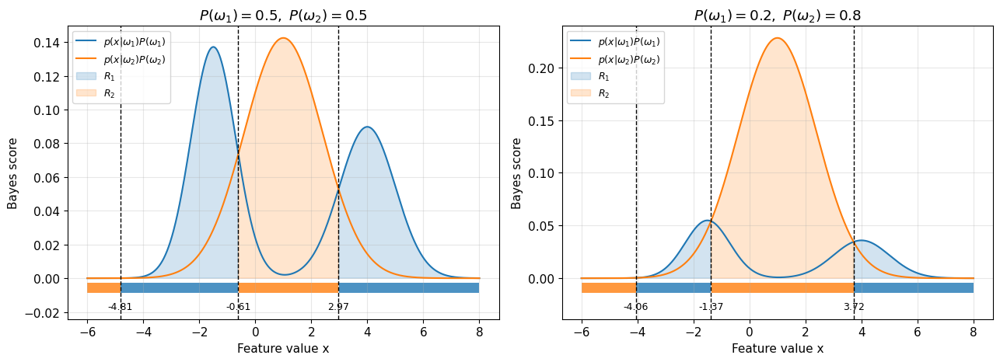

In [6]:
# ------------------------------------------------------------
# Non-Gaussian example
# ------------------------------------------------------------

x_mix = np.linspace(-6, 8, 1200)

# p(x | w1): bimodal Gaussian mixture
p_x_w1_mix = (
    0.55 * norm.pdf(x_mix, loc=-1.5, scale=0.8)
    + 0.45 * norm.pdf(x_mix, loc=4.0, scale=1.0)
)

# p(x | w2): single Gaussian
p_x_w2_mix = norm.pdf(x_mix, loc=1.0, scale=1.4)


def bayes_regions_1d(x, density1, density2, prior1, prior2):
    score1 = density1 * prior1
    score2 = density2 * prior2

    predict_w1 = score1 >= score2

    change_idx = np.where(np.diff(predict_w1.astype(int)) != 0)[0]
    boundaries = (x[change_idx] + x[change_idx + 1]) / 2

    return score1, score2, predict_w1, boundaries


cases = [
    (0.5, 0.5),
    (0.2, 0.8),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for ax, (P_w1, P_w2) in zip(axes, cases):
    score1, score2, predict_w1, boundaries = bayes_regions_1d(
        x_mix, p_x_w1_mix, p_x_w2_mix, P_w1, P_w2,
    )
    top = np.maximum(score1, score2)

    ax.plot(x_mix, score1, color=COL1, label=r"$p(x|\omega_1)P(\omega_1)$")
    ax.plot(x_mix, score2, color=COL2, label=r"$p(x|\omega_2)P(\omega_2)$")

    ax.fill_between(x_mix, 0, top, where=predict_w1,
                    color=COL1, alpha=0.2, label=r"$R_1$")
    ax.fill_between(x_mix, 0, top, where=~predict_w1,
                    color=COL2, alpha=0.2, label=r"$R_2$")

    # Region bar along the x-axis: makes the tiny left-tail R_2 visible
    ymax = top.max()
    ax.fill_between(x_mix, -0.06 * ymax, -0.02 * ymax, where=predict_w1,
                    color=COL1, alpha=0.8, linewidth=0)
    ax.fill_between(x_mix, -0.06 * ymax, -0.02 * ymax, where=~predict_w1,
                    color=COL2, alpha=0.8, linewidth=0)

    for boundary in boundaries:
        ax.axvline(boundary, color="k", linestyle="--", linewidth=1)
        ax.text(boundary, -0.13 * ymax, f"{boundary:.2f}",
                ha="center", fontsize=9)

    ax.set_ylim(-0.17 * ymax, 1.05 * ymax)
    ax.set_xlabel("Feature value x")
    ax.set_ylabel("Bayes score")
    ax.set_title(rf"$P(\omega_1)={P_w1:.1f},\;P(\omega_2)={P_w2:.1f}$")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

### What should we notice?

- The Bayes classifier is **not restricted to one threshold**: here the regions are $R_2 \rightarrow R_1 \rightarrow R_2 \rightarrow R_1$ (colored bar under each plot). Decision regions need not be connected.
- The small $R_2$ on the far left is real: $p(x\mid\omega_2)$ is wider ($\sigma=1.4$) than the left mixture component ($\sigma=0.8$), so its tail eventually dominates.
- Changing the priors rescales $p(x\mid\omega_i)P(\omega_i)$, so a region can grow, shrink, or disappear.

#### Animation: sweep $P(\omega_1)$ for the bimodal class

Watch the colored bar under the curves: regions grow, shrink, and the small $R_2$ pieces disappear at extreme priors, so the number of boundaries changes.

In [7]:
prior_sweep_mix = np.linspace(0.05, 0.95, 19)
ymax_mix = max(np.maximum(p_x_w1_mix * p, p_x_w2_mix * (1 - p)).max()
               for p in prior_sweep_mix)

fig, ax = plt.subplots(figsize=(9, 4.8))
fig.subplots_adjust(top=0.9, bottom=0.12)


def update(k):
    P_w1 = prior_sweep_mix[k]
    P_w2 = 1 - P_w1
    score1, score2, predict_w1, boundaries = bayes_regions_1d(
        x_mix, p_x_w1_mix, p_x_w2_mix, P_w1, P_w2,
    )
    top = np.maximum(score1, score2)

    ax.cla()
    ax.plot(x_mix, score1, color=COL1, label=r"$p(x|\omega_1)P(\omega_1)$")
    ax.plot(x_mix, score2, color=COL2, label=r"$p(x|\omega_2)P(\omega_2)$")
    ax.fill_between(x_mix, 0, top, where=predict_w1, color=COL1, alpha=0.2, label=r"$R_1$")
    ax.fill_between(x_mix, 0, top, where=~predict_w1, color=COL2, alpha=0.2, label=r"$R_2$")

    # Region bar along the x-axis
    ax.fill_between(x_mix, -0.06 * ymax_mix, -0.02 * ymax_mix, where=predict_w1,
                    color=COL1, alpha=0.8, linewidth=0)
    ax.fill_between(x_mix, -0.06 * ymax_mix, -0.02 * ymax_mix, where=~predict_w1,
                    color=COL2, alpha=0.8, linewidth=0)

    for boundary in boundaries:
        ax.axvline(boundary, color="k", linestyle="--", linewidth=1)
        ax.text(boundary, -0.13 * ymax_mix, f"{boundary:.2f}", ha="center", fontsize=9)

    ax.set_ylim(-0.17 * ymax_mix, 1.05 * ymax_mix)
    ax.set_xlabel("Feature value x")
    ax.set_ylabel("Bayes score")
    ax.set_title(rf"$P(\omega_1)={P_w1:.2f},\;P(\omega_2)={P_w2:.2f}$"
                 f"   (number of boundaries: {len(boundaries)})")
    ax.legend(loc="upper left", fontsize=9)


show_animation(fig, update, frames=len(prior_sweep_mix), interval=250)

## 4. Effect of priors on the Bayes decision boundary

Two 2-D Gaussian classes with the **same covariance matrix**. Since $p(\mathbf{x})$ is the same for every class, we only compare

$$p(\mathbf{x}\mid\omega_1)P(\omega_1)\quad\text{and}\quad p(\mathbf{x}\mid\omega_2)P(\omega_2).$$

The densities stay fixed; only the priors change: $P(\omega_1)=P(\omega_2)=0.5$ vs. $P(\omega_1)=0.1,\;P(\omega_2)=0.9$.

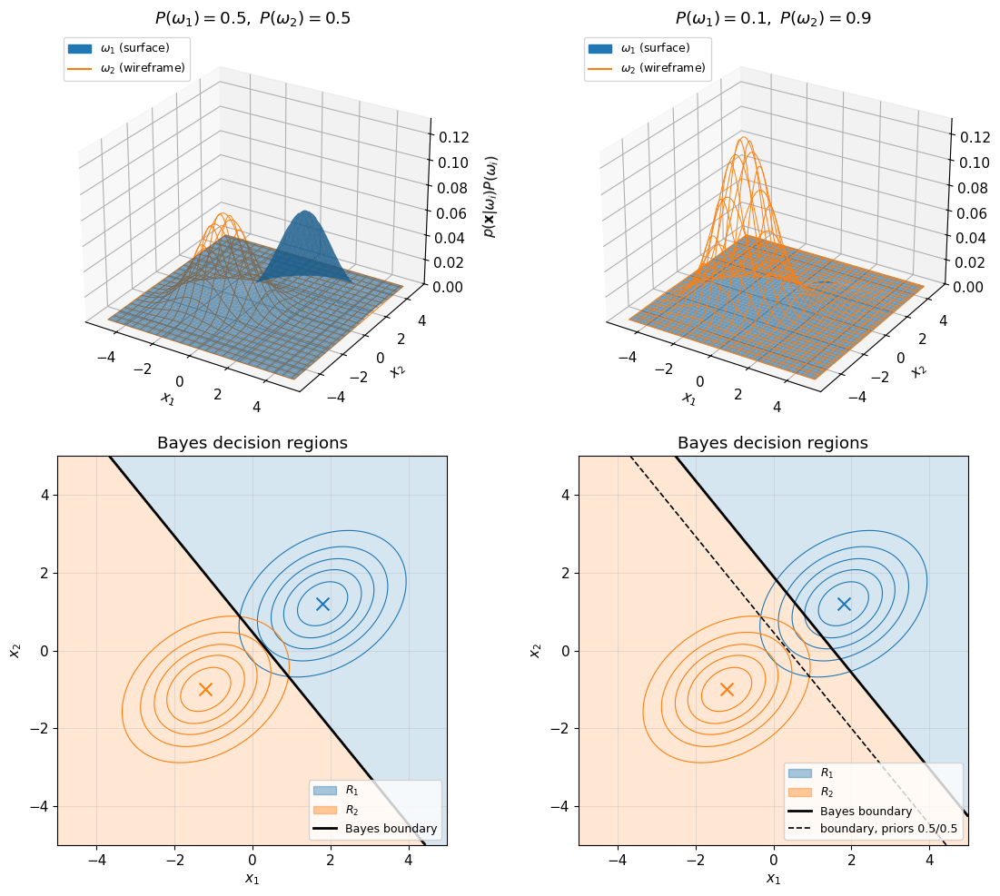

In [8]:
# ------------------------------------------------------------
# Two 2-D Gaussian classes with the SAME covariance matrix
# ------------------------------------------------------------

mu1 = np.array([1.8, 1.2])
mu2 = np.array([-1.2, -1.0])

Sigma = np.array([
    [1.3, 0.35],
    [0.35, 1.0],
])

class_1 = multivariate_normal(mean=mu1, cov=Sigma)
class_2 = multivariate_normal(mean=mu2, cov=Sigma)

# Create a 2-D grid.
g1 = np.linspace(-5, 5, 180)
g2 = np.linspace(-5, 5, 180)

G1, G2 = np.meshgrid(g1, g2)
GRID = np.stack([G1, G2], axis=-1)

# These class-conditional densities DO NOT change
# when we change the priors.
pdf1 = class_1.pdf(GRID)   # p(x | w1)
pdf2 = class_2.pdf(GRID)   # p(x | w2)

# Same z-scale for both 3-D plots, so the rescaling by the prior is visible
ZMAX = 0.9 * max(pdf1.max(), pdf2.max())


def plot_prior_case(ax_3d, ax_2d, prior1, prior2, reference_priors=None):
    """
    Visualize one Bayes-classification problem.

    prior1 = P(w1)
    prior2 = P(w2)
    reference_priors: optional (P1, P2) whose boundary is drawn dashed
    """

    # Bayes scores: p(x | wi) P(wi)
    score1 = pdf1 * prior1
    score2 = pdf2 * prior2

    # Minimum-error Bayes rule: choose the class with the larger score.
    predict_w1 = score1 >= score2

    # The decision boundary occurs where score1 - score2 = 0.
    score_difference = score1 - score2

    # --------------------------------------------------------
    # Top plot: weighted class-conditional densities
    # --------------------------------------------------------
    ax_3d.plot_surface(G1, G2, score1, color=COL1, alpha=0.6, linewidth=0)
    ax_3d.plot_wireframe(G1, G2, score2, color=COL2,
                         rstride=8, cstride=8, linewidth=0.7)
    ax_3d.set_zlim(0, ZMAX)

    ax_3d.set_xlabel(r"$x_1$")
    ax_3d.set_ylabel(r"$x_2$")
    ax_3d.set_zlabel(r"$p(\mathbf{x}|\omega_i)P(\omega_i)$", labelpad=10)
    ax_3d.set_title(rf"$P(\omega_1)={prior1:.1f},\;P(\omega_2)={prior2:.1f}$")
    ax_3d.legend(handles=[
        Patch(color=COL1, label=r"$\omega_1$ (surface)"),
        Line2D([], [], color=COL2, label=r"$\omega_2$ (wireframe)"),
    ], loc="upper left", fontsize=9)
    ax_3d.view_init(elev=27, azim=-58)

    # --------------------------------------------------------
    # Bottom plot: Bayes decision regions
    # --------------------------------------------------------
    ax_2d.contourf(G1, G2, predict_w1.astype(int),
                   levels=[-0.5, 0.5, 1.5],
                   cmap=ListedColormap([COL2, COL1]), alpha=0.18)

    # Original (unweighted) Gaussian shapes
    ax_2d.contour(G1, G2, pdf1, levels=5, colors=COL1, linewidths=0.8)
    ax_2d.contour(G1, G2, pdf2, levels=5, colors=COL2, linewidths=0.8)

    # Bayes decision boundary
    ax_2d.contour(G1, G2, score_difference, levels=[0],
                  colors="k", linewidths=2)

    handles = [
        Patch(color=COL1, alpha=0.4, label=r"$R_1$"),
        Patch(color=COL2, alpha=0.4, label=r"$R_2$"),
        Line2D([], [], color="k", lw=2, label="Bayes boundary"),
    ]

    if reference_priors is not None:
        r1, r2 = reference_priors
        ax_2d.contour(G1, G2, pdf1 * r1 - pdf2 * r2, levels=[0],
                      colors="k", linewidths=1.2, linestyles="--")
        handles.append(Line2D([], [], color="k", lw=1.2, ls="--",
                              label=f"boundary, priors {r1}/{r2}"))

    # Class means
    ax_2d.scatter(*mu1, marker="x", s=100, color=COL1, zorder=3)
    ax_2d.scatter(*mu2, marker="x", s=100, color=COL2, zorder=3)

    ax_2d.set_xlim(-5, 5)
    ax_2d.set_ylim(-5, 5)
    ax_2d.set_aspect("equal")
    ax_2d.set_xlabel(r"$x_1$")
    ax_2d.set_ylabel(r"$x_2$")
    ax_2d.set_title("Bayes decision regions")
    ax_2d.legend(handles=handles, loc="lower right", fontsize=9)


# ------------------------------------------------------------
# Compare two different prior settings
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 10))

ax1 = fig.add_subplot(2, 2, 1, projection="3d")
ax2 = fig.add_subplot(2, 2, 2, projection="3d")
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

plot_prior_case(ax1, ax3, prior1=0.5, prior2=0.5)
plot_prior_case(ax2, ax4, prior1=0.1, prior2=0.9, reference_priors=(0.5, 0.5))

plt.tight_layout()
plt.show()

### What changes when the prior changes?

- **Top:** the Gaussian shapes are fixed; the prior only rescales them.
- **Bottom:** with $P(\omega_2)=0.9$, the classifier needs **stronger evidence for $\omega_1$**, so $R_2$ grows and the boundary shifts toward $\mu_1$.
- Because both classes share the same covariance, the boundary remains linear.

#### Animation: sweep $P(\omega_1)$ in 2-D

Left: the prior rescales the height of each Gaussian. Right: the boundary slides parallel to itself (dashed = equal priors), always away from the more probable class.

In [9]:
prior_sweep_2d = np.linspace(0.05, 0.95, 11)

fig = plt.figure(figsize=(13, 5.5))
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
ax_2d = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(left=0.0, right=0.97, wspace=0.05)


def update(k):
    p1 = prior_sweep_2d[k]
    ax_3d.cla()
    ax_2d.cla()
    plot_prior_case(ax_3d, ax_2d, prior1=p1, prior2=1 - p1, reference_priors=(0.5, 0.5))
    ax_3d.set_title(rf"$P(\omega_1)={p1:.2f},\;P(\omega_2)={1 - p1:.2f}$")


show_animation(fig, update, frames=len(prior_sweep_2d), interval=400)

## 6. Multivariate Gaussian classifiers

For a $d$-dimensional Gaussian,

$$p(\mathbf{x}\mid\omega_i)
=
\frac{1}
{(2\pi)^{d/2}|\Sigma_i|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\mu_i)^T
\Sigma_i^{-1}
(\mathbf{x}-\mu_i)
\right].$$

The quantity

$$(\mathbf{x}-\mu)^T\Sigma^{-1}(\mathbf{x}-\mu)$$

is the squared **Mahalanobis distance**.


For classification we use the **discriminant function** (log is monotonic, and numerically more stable):

$$g_i(\mathbf{x})=\ln p(\mathbf{x}\mid\omega_i)+\ln P(\omega_i).$$

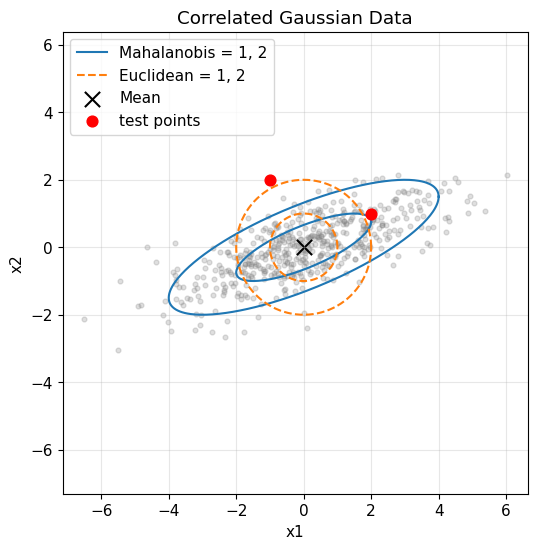

Point: [2. 1.] | squared Euclidean: 5.0 | squared Mahalanobis: 1.143
Point: [-1.  2.] | squared Euclidean: 5.0 | squared Mahalanobis: 13.143


In [10]:
# Visualize Euclidean vs Mahalanobis distance intuition.

mu = np.array([0.0, 0.0])

Sigma_m = np.array([
    [4.0, 1.5],
    [1.5, 1.0],
])

points = rng.multivariate_normal(mu, Sigma_m, size=500)

# Unit-circle -> curves of constant distance
theta = np.linspace(0, 2 * np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])
L = np.linalg.cholesky(Sigma_m)

plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], alpha=0.25, color="gray", s=12)
for r in [1, 2]:
    ell = mu[:, None] + r * L @ circle          # Mahalanobis distance = r
    plt.plot(ell[0], ell[1], color=COL1,
             label="Mahalanobis = 1, 2" if r == 1 else None)
    plt.plot(r * circle[0], r * circle[1], color=COL2, linestyle="--",
             label="Euclidean = 1, 2" if r == 1 else None)
plt.scatter(*mu, marker="x", s=120, color="k", label="Mean")
# Two test points with the same Euclidean distance √5
test_pts = np.array([[2.0, 1.0], [-1.0, 2.0]])
plt.scatter(test_pts[:, 0], test_pts[:, 1], s=60, color="red", zorder=3,
            label="test points")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Correlated Gaussian Data")
plt.axis("equal")
plt.legend(loc="upper left")
plt.show()

# Same Euclidean distance, very different Mahalanobis distance
Sigma_inv = np.linalg.inv(Sigma_m)
for p in test_pts:
    d = p - mu
    print("Point:", p, "| squared Euclidean:", round(d @ d, 3),
          "| squared Mahalanobis:", round(d @ Sigma_inv @ d, 3))

## 7. Gaussian classifier — Case 1

### Shared spherical covariance

$$\Sigma_i=\sigma^2 I$$

for every class.

With equal priors, the Bayes classifier reduces to a **nearest-mean classifier using Euclidean distance**.

The decision boundary is linear.

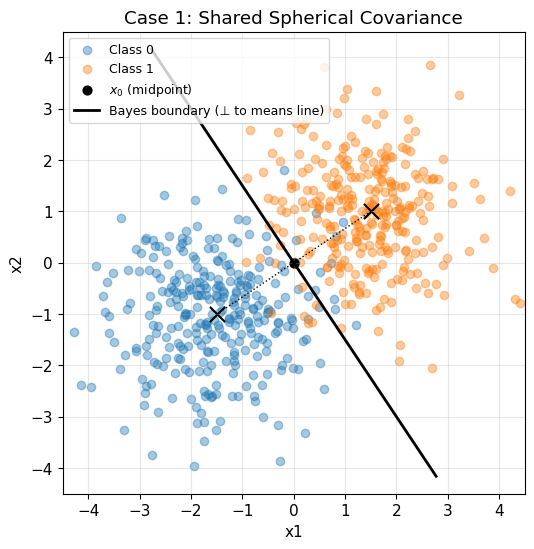

In [11]:
# Two classes with the same spherical covariance.

mean0 = np.array([-1.5, -1.0])
mean1 = np.array([ 1.5,  1.0])

cov_shared_spherical = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
])

X0 = rng.multivariate_normal(mean0, cov_shared_spherical, size=300)
X1 = rng.multivariate_normal(mean1, cov_shared_spherical, size=300)

X = np.vstack([X0, X1])
y = np.concatenate([
    np.zeros(len(X0), dtype=int),
    np.ones(len(X1), dtype=int),
])

# Equal priors -> boundary is the perpendicular bisector of the means:
#   w^T (x - x0) = 0,   w = mean1 - mean0,   x0 = (mean0 + mean1) / 2
w = mean1 - mean0
x0 = (mean0 + mean1) / 2
t = np.linspace(-5, 5, 2)
direction = np.array([-w[1], w[0]]) / np.linalg.norm(w)
boundary_pts = x0[:, None] + direction[:, None] * t

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.4, color=COL1, label="Class 0")
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.4, color=COL2, label="Class 1")
plt.plot([mean0[0], mean1[0]], [mean0[1], mean1[1]], "k:", linewidth=1)
plt.scatter(*mean0, marker="x", s=120, color="k")
plt.scatter(*mean1, marker="x", s=120, color="k")
plt.scatter(*x0, marker="o", s=40, color="k", label=r"$x_0$ (midpoint)")
plt.plot(boundary_pts[0], boundary_pts[1], "k", linewidth=2,
         label="Bayes boundary (⊥ to means line)")
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.gca().set_aspect("equal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Case 1: Shared Spherical Covariance")
plt.legend(loc="upper left", fontsize=9)
plt.show()

## 8. Gaussian classifier — Case 2

### Shared arbitrary covariance

$$\Sigma_i=\Sigma$$

for every class.

The decision boundary remains **linear**, but Euclidean distance is replaced by a covariance-aware distance.

This is closely related to **Linear Discriminant Analysis (LDA)**.

In [12]:
# Create a dataset with correlated features but the same covariance
# for both classes.

shared_cov = np.array([
    [2.0, 1.2],
    [1.2, 1.5],
])

X0 = rng.multivariate_normal(
    mean=[-1.5, -1.0],
    cov=shared_cov,
    size=400,
)

X1 = rng.multivariate_normal(
    mean=[1.5, 1.0],
    cov=shared_cov,
    size=400,
)

X_lda = np.vstack([X0, X1])
y_lda = np.concatenate([
    np.zeros(len(X0), dtype=int),
    np.ones(len(X1), dtype=int),
])

lda = LinearDiscriminantAnalysis()
lda.fit(X_lda, y_lda)

print("LDA training accuracy:",
      round(lda.score(X_lda, y_lda), 3))


LDA training accuracy: 0.851


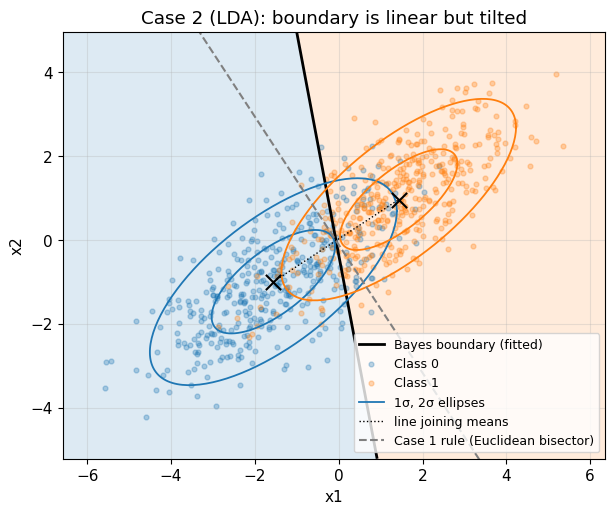

Angle between w = Σ⁻¹(μ1-μ0) and (μ1-μ0): 22.5°  (0° would mean Case 1)


In [13]:
# Plot the LDA decision boundary (plot_boundary is defined in the setup cell).
# For comparison, also draw the Case-1 rule (perpendicular bisector of the means).

m0, m1 = X0.mean(axis=0), X1.mean(axis=0)
d = m1 - m0
mid = (m0 + m1) / 2
perp = np.array([-d[1], d[0]]) / np.linalg.norm(d)
t = np.linspace(-10, 10, 2)

fig, ax = plt.subplots(figsize=(7, 7))
plot_boundary(lda, X0, X1, ax, "Case 2 (LDA): boundary is linear but tilted")
ax.plot([m0[0], m1[0]], [m0[1], m1[1]], "k:", linewidth=1, label="line joining means")
ax.plot(mid[0] + t * perp[0], mid[1] + t * perp[1], color="gray",
        linestyle="--", linewidth=1.5, label="Case 1 rule (Euclidean bisector)")
ax.legend(loc="lower right", fontsize=9)
plt.show()

# Normal vector of the boundary: w = Sigma^{-1} (mu1 - mu0)
w = np.linalg.solve(np.cov(np.vstack([X0 - m0, X1 - m1]).T), d)
angle = np.degrees(np.arccos(w @ d / np.linalg.norm(w) / np.linalg.norm(d)))
print(f"Angle between w = Σ⁻¹(μ1-μ0) and (μ1-μ0): {angle:.1f}°  (0° would mean Case 1)")

#### Animation: from Case 1 to Case 2

The shared covariance is morphed from $I$ to the correlated $\Sigma$ used above, $\Sigma(t)=(1-t)I+t\,\Sigma$, with equal priors. The boundary stays linear and always passes through the midpoint of the means, but its normal $\mathbf w=\Sigma^{-1}(\mu_1-\mu_0)$ tilts away from the line joining the means.

In [14]:
mu0_true, mu1_true = np.array([-1.5, -1.0]), np.array([1.5, 1.0])
d_true = mu1_true - mu0_true
mid_true = (mu0_true + mu1_true) / 2
t_sweep = np.linspace(0, 1, 16)

gx1, gx2 = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
unit_circle = np.stack([np.cos(np.linspace(0, 2 * np.pi, 200)),
                        np.sin(np.linspace(0, 2 * np.pi, 200))])
s_line = np.linspace(-12, 12, 2)
perp_d = np.array([-d_true[1], d_true[0]]) / np.linalg.norm(d_true)

fig, ax = plt.subplots(figsize=(7, 7))


def update(k):
    t_k = t_sweep[k]
    S_k = (1 - t_k) * np.eye(2) + t_k * shared_cov
    w_k = np.linalg.solve(S_k, d_true)          # normal vector of the boundary

    ax.cla()
    # Decision regions: sign of w^T (x - midpoint)
    side = w_k[0] * (gx1 - mid_true[0]) + w_k[1] * (gx2 - mid_true[1]) > 0
    ax.contourf(gx1, gx2, side.astype(int), levels=[-0.5, 0.5, 1.5],
                cmap=ListedColormap([COL1, COL2]), alpha=0.15)

    # 1-sigma and 2-sigma ellipses of each class
    L_k = np.linalg.cholesky(S_k)
    for m, col in [(mu0_true, COL1), (mu1_true, COL2)]:
        for r in [1, 2]:
            e = m[:, None] + r * L_k @ unit_circle
            ax.plot(e[0], e[1], color=col, linewidth=1.3)
        ax.scatter(*m, marker="x", s=120, color="k", zorder=4)

    perp_w = np.array([-w_k[1], w_k[0]]) / np.linalg.norm(w_k)
    ax.plot(mid_true[0] + s_line * perp_w[0], mid_true[1] + s_line * perp_w[1],
            "k", linewidth=2, label=r"Bayes boundary, normal $w=\Sigma^{-1}(\mu_1-\mu_0)$")
    ax.plot(mid_true[0] + s_line * perp_d[0], mid_true[1] + s_line * perp_d[1],
            color="gray", linestyle="--", linewidth=1.5, label="Case 1 rule (Euclidean bisector)")
    ax.plot([mu0_true[0], mu1_true[0]], [mu0_true[1], mu1_true[1]], "k:", linewidth=1,
            label="line joining means")

    cos_ang = w_k @ d_true / np.linalg.norm(w_k) / np.linalg.norm(d_true)
    ang = np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))
    ax.set_title(rf"$\Sigma(t)=(1-t)I+t\,\Sigma$,   t = {t_k:.2f}" + "\n"
                 + f"angle between w and μ1 − μ0: {ang:.1f}°")
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(loc="lower right", fontsize=9)


show_animation(fig, update, frames=len(t_sweep), interval=250)

## 9. Gaussian classifier — Case 3

### Class-specific covariance $\Sigma_i$

The Gaussian discriminant contains quadratic terms, so the decision boundary can become curved (**QDA**).

Below we fit both models to the same data:

- **LDA** assumes the classes share a covariance matrix.
- **QDA** allows each class to have its own covariance matrix.

The ellipses show each class's estimated covariance: they clearly differ, but LDA forces one shared $\Sigma$ and can only draw a straight line.

In [15]:
cov0 = np.array([
    [2.5, 1.3],
    [1.3, 1.0],
])

cov1 = np.array([
    [1.0, -0.4],
    [-0.4, 2.2],
])

X0_qda = rng.multivariate_normal(
    mean=[-1.5, 0.0],
    cov=cov0,
    size=400,
)

X1_qda = rng.multivariate_normal(
    mean=[1.5, 0.5],
    cov=cov1,
    size=400,
)

X_qda = np.vstack([X0_qda, X1_qda])
y_qda = np.concatenate([
    np.zeros(len(X0_qda), dtype=int),
    np.ones(len(X1_qda), dtype=int),
])

LDA accuracy: 0.884
QDA accuracy: 0.894


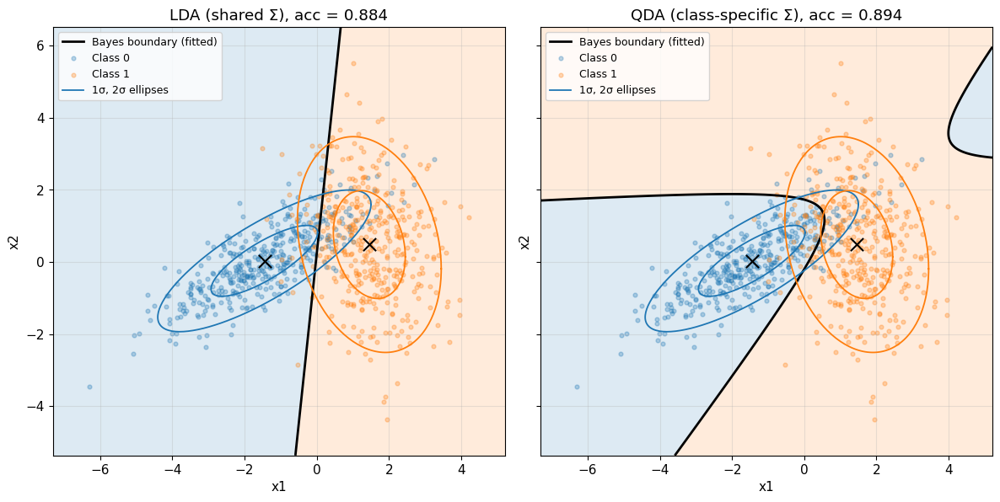

In [16]:
lda_on_qda_data = LinearDiscriminantAnalysis()
qda_on_qda_data = QuadraticDiscriminantAnalysis()

lda_on_qda_data.fit(X_qda, y_qda)
qda_on_qda_data.fit(X_qda, y_qda)

acc_lda = lda_on_qda_data.score(X_qda, y_qda)
acc_qda = qda_on_qda_data.score(X_qda, y_qda)

print("LDA accuracy:", round(acc_lda, 3))
print("QDA accuracy:", round(acc_qda, 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
plot_boundary(lda_on_qda_data, X0_qda, X1_qda, axes[0],
              f"LDA (shared Σ), acc = {acc_lda:.3f}")
plot_boundary(qda_on_qda_data, X0_qda, X1_qda, axes[1],
              f"QDA (class-specific Σ), acc = {acc_qda:.3f}")
plt.tight_layout()
plt.show()

# The second QDA boundary branch far from the data is genuine:
# a quadratic boundary can be a hyperbola, so a region need not be connected.

## 10. Real problem: breast-cancer diagnosis

A doctor takes a fine-needle biopsy of a breast mass. Software measures the cell nuclei in the microscope image. **Should this patient be sent for further treatment (malignant) or sent home (benign)?**

Dataset: *Wisconsin Diagnostic Breast Cancer* (built into scikit-learn), 569 tumors, 212 malignant / 357 benign. To keep everything visible in 2-D, we use two features:

- `mean radius`: size of the cell nuclei
- `mean texture`: variation in gray level inside the nuclei

Every concept from this recitation shows up in this problem:

| Lecture concept | What it is here |
|---|---|
| Classes $\omega_i$ | malignant (label 1) and benign (label 0) |
| Features $\mathbf{x}$ | the two measurements of one tumor: (mean radius, mean texture) |
| Likelihood (class-conditional density) $p(\mathbf{x}\mid\omega_i)$ | how the measurements are spread among malignant tumors, and among benign tumors. Modeled as one 2-D Gaussian per class, each with its own covariance (QDA) |
| Prior $P(\omega_i)$ | how common malignant tumors are *before* we look at $\mathbf{x}$: 37% in this dataset, 10% in the (hypothetical) clinic of Step 1 |
| Posterior $P(\omega_i\mid\mathbf{x})$ | the probability that *this* tumor is malignant, given its measurements |
| Actions $\alpha_i$ | send the patient to biopsy (say malignant) or send them home (say benign) |
| Loss $\lambda(\alpha_i\mid\omega_j)$ | the cost of each mistake: a missed cancer (10) is far worse than an unnecessary biopsy (1) |
| Decision rule | Step 1, **min-error** (0-1 loss): biopsy if $P(\text{malignant}\mid\mathbf{x}) > 0.5$. Step 2, **min-risk**: biopsy already if $P(\text{malignant}\mid\mathbf{x}) > 1/11 \approx 0.09$. Both are Bayes rules; they differ only in the loss |

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
features = ["mean radius", "mean texture"]
idx = [list(data.feature_names).index(f) for f in features]

X_bc = data.data[:, idx]
y_bc = (data.target == 0).astype(int)   # 1 = malignant, 0 = benign (sklearn uses 0 = malignant)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=0, stratify=y_bc,
)

# Gaussian class-conditional densities with class-specific covariance.
# The priors are estimated from the training data.
qda_bc = QuadraticDiscriminantAnalysis().fit(X_tr, y_tr)

print("Tumors:", len(y_bc), "| malignant:", y_bc.sum(), "| benign:", (1 - y_bc).sum())
print("Prior P(malignant) from training data:", round(qda_bc.priors_[1], 3))
print("Test accuracy (min-error rule):", round(qda_bc.score(X_te, y_te), 3))

Tumors: 569 | malignant: 212 | benign: 357
Prior P(malignant) from training data: 0.372
Test accuracy (min-error rule): 0.901


### Step 1 — Min-error rule (0-1 loss)

The **min-error** rule is the Bayes rule when every mistake costs the same (0-1 loss): predict the class with the larger posterior, i.e. predict malignant if $P(\text{malignant}\mid\mathbf{x}) > 0.5$.

Background color = posterior $P(\text{malignant}\mid\mathbf{x})$. The black line is the min-error boundary $P=0.5$. (The orange strip in the upper-left corner has no data: QDA gives the malignant class a wider Gaussian, so its tail wins there, the same effect as in Section 3.)

Take a borderline patient (★): a malignant tumor whose posterior is only about 0.3.

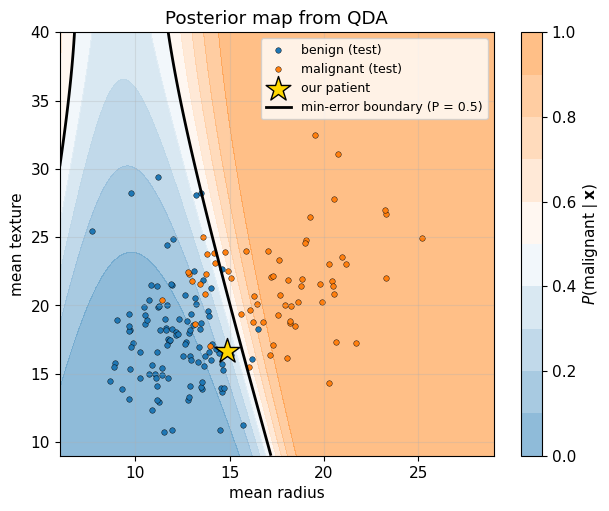

Patient: mean radius = 14.87, mean texture = 16.67
P(malignant | x) = 0.286
Min-error decision: benign
Ground truth for this patient: MALIGNANT


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

post_cmap = LinearSegmentedColormap.from_list("post", [COL1, "white", COL2])

# Grid covering the data range (mean radius, mean texture)
RR, TT = np.meshgrid(np.linspace(6, 29, 300), np.linspace(9, 40, 300))
grid_bc = np.c_[RR.ravel(), TT.ravel()]


def posterior_map(model):
    return model.predict_proba(grid_bc)[:, 1].reshape(RR.shape)


def draw_base(ax, post, title):
    im = ax.contourf(RR, TT, post, levels=np.linspace(0, 1, 11),
                     cmap=post_cmap, alpha=0.55)
    ax.scatter(*X_te[y_te == 0].T, s=16, color=COL1, edgecolor="k",
               linewidth=0.3, label="benign (test)")
    ax.scatter(*X_te[y_te == 1].T, s=16, color=COL2, edgecolor="k",
               linewidth=0.3, label="malignant (test)")
    ax.scatter(*x_patient, marker="*", s=350, color="gold",
               edgecolor="k", zorder=5, label="our patient")
    ax.set_xlabel(features[0])
    ax.set_ylabel(features[1])
    ax.set_title(title)
    return im


# Pick a borderline test patient: posterior around 0.3
p_te = qda_bc.predict_proba(X_te)[:, 1]
malignant_idx = np.where(y_te == 1)[0]
patient = malignant_idx[np.argmin(np.abs(p_te[malignant_idx] - 0.3))]
x_patient = X_te[patient]

post_bc = posterior_map(qda_bc)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = draw_base(ax, post_bc, "Posterior map from QDA")
ax.contour(RR, TT, post_bc, levels=[0.5], colors="k", linewidths=2)
ax.plot([], [], color="k", linewidth=2, label="min-error boundary (P = 0.5)")
fig.colorbar(im, ax=ax, label=r"$P(\mathrm{malignant}\mid\mathbf{x})$")
ax.legend(loc="upper right", fontsize=9)
plt.show()

# ---- Min-error decision for this patient: the larger posterior wins ----
P_m = qda_bc.predict_proba(x_patient[None])[0, 1]

print(f"Patient: {features[0]} = {x_patient[0]:.2f}, {features[1]} = {x_patient[1]:.2f}")
print(f"P(malignant | x) = {P_m:.3f}")
print("Min-error decision:", "malignant" if P_m > 0.5 else "benign")
print("Ground truth for this patient:", "MALIGNANT" if y_te[patient] == 1 else "benign")

#### The prior moves the min-error boundary

This dataset is ~37% malignant. Suppose the same software is used in a clinic where only **10%** of masses are malignant (a hypothetical number). The measurements $\mathbf{x}$ and $p(\mathbf{x}\mid\omega_i)$ are the same, but the posterior $\propto p(\mathbf{x}\mid\omega_i)P(\omega_i)$ changes, so the min-error boundary $P = 0.5$ moves.

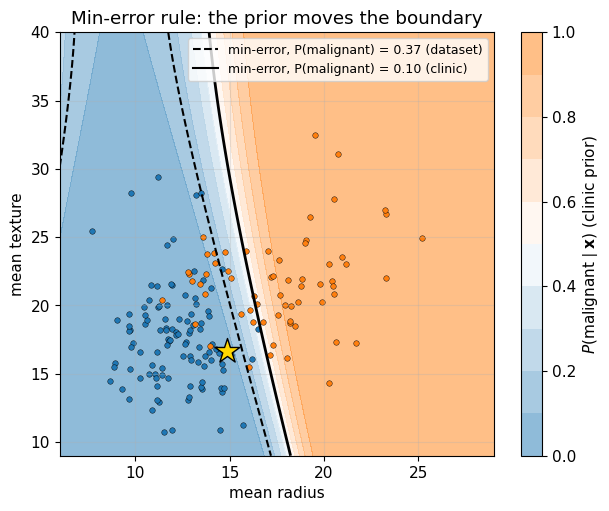

Our patient: P(malignant | x) = 0.286 (dataset prior) -> 0.070 (clinic prior)


In [32]:
# Same Gaussians, different prior: P(malignant) = 0.10
qda_clinic = QuadraticDiscriminantAnalysis(priors=[0.90, 0.10]).fit(X_tr, y_tr)
post_clinic = posterior_map(qda_clinic)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = draw_base(ax, post_clinic, "Min-error rule: the prior moves the boundary")
ax.contour(RR, TT, post_bc, levels=[0.5], colors="k", linestyles="--", linewidths=1.5)
ax.contour(RR, TT, post_clinic, levels=[0.5], colors="k", linewidths=2)
fig.colorbar(im, ax=ax, label=r"$P(\mathrm{malignant}\mid\mathbf{x})$ (clinic prior)")
ax.legend(handles=[
    Line2D([], [], color="k", ls="--", label=f"min-error, P(malignant) = {qda_bc.priors_[1]:.2f} (dataset)"),
    Line2D([], [], color="k", label="min-error, P(malignant) = 0.10 (clinic)"),
], loc="upper right", fontsize=9)
plt.show()

P_m_clinic = qda_clinic.predict_proba(x_patient[None])[0, 1]
print(f"Our patient: P(malignant | x) = {P_m:.3f} (dataset prior) -> {P_m_clinic:.3f} (clinic prior)")

### Step 2 — Min-risk rule (a missed cancer costs more)

The two mistakes are not equally bad. Assume a **missed cancer costs 10** and an **unnecessary biopsy costs 1** (an assumed cost ratio, for illustration):

| | truth: benign | truth: malignant |
|---|---|---|
| say benign (send home) | 0 | $\lambda_{FN} = 10$ |
| say malignant (biopsy) | $\lambda_{FP} = 1$ | 0 |

The **min-risk** rule picks the action with the smaller conditional risk:

$$R(\text{say benign}\mid\mathbf{x}) = 10\,P(\text{malignant}\mid\mathbf{x}),\qquad
R(\text{say malignant}\mid\mathbf{x}) = 1\cdot P(\text{benign}\mid\mathbf{x}).$$

So it predicts malignant when $\lambda_{FP}P(\text{benign}\mid\mathbf{x}) < \lambda_{FN}P(\text{malignant}\mid\mathbf{x})$, i.e.

$$P(\text{malignant}\mid\mathbf{x}) > \frac{\lambda_{FP}}{\lambda_{FP}+\lambda_{FN}} = \frac{1}{11}\approx 0.09.$$

With 0-1 loss ($\lambda_{FP} = \lambda_{FN} = 1$) the threshold is $1/2$: the min-error rule of Step 1 is a special case. **Both are Bayes rules; only the loss differs.**

With the min-risk rule, only tumors that look *clearly* benign (inside the solid curve) are sent home.

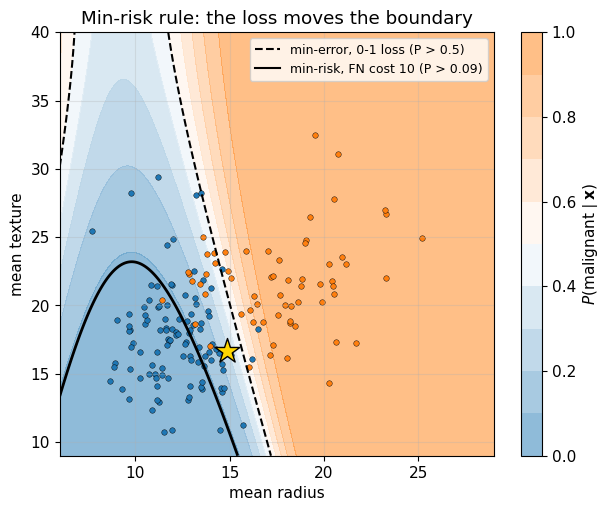

Our patient: P(malignant | x) = 0.286
Risk(say benign) = 2.862,  Risk(say malignant) = 0.714
Min-error decision: benign
Min-risk decision:  malignant

Test set: 64 malignant, 107 benign

min-error (P > 0.5): missed cancers = 14, unnecessary biopsies =  3, total cost = 143
min-risk  (P > 0.09): missed cancers =  1, unnecessary biopsies = 42, total cost = 52


In [ ]:
# Cost of each mistake
loss_FP = 1    # benign tumor sent to biopsy
loss_FN = 10   # malignant tumor sent home
thr = loss_FP / (loss_FP + loss_FN)    # min-risk threshold on P(malignant | x)

# ---- Min-risk decision for our patient: the smaller risk wins ----
risk_say_benign = loss_FN * P_m
risk_say_malignant = loss_FP * (1 - P_m)

# ---- The loss moves the boundary: threshold 0.5 -> 1/11 ----
fig, ax = plt.subplots(figsize=(7, 5.5))
im = draw_base(ax, post_bc, "Min-risk rule: the loss moves the boundary")
ax.contour(RR, TT, post_bc, levels=[0.5], colors="k", linestyles="--", linewidths=1.5)
ax.contour(RR, TT, post_bc, levels=[thr], colors="k", linewidths=2)
fig.colorbar(im, ax=ax, label=r"$P(\mathrm{malignant}\mid\mathbf{x})$")
ax.legend(handles=[
    Line2D([], [], color="k", ls="--", label="min-error, 0-1 loss (P > 0.5)"),
    Line2D([], [], color="k", label=f"min-risk, FN cost {loss_FN} (P > {thr:.2f})"),
], loc="upper right", fontsize=9)
plt.show()

print(f"Our patient: P(malignant | x) = {P_m:.3f}")
print(f"Risk(say benign) = {risk_say_benign:.3f},  Risk(say malignant) = {risk_say_malignant:.3f}")
print("Min-error decision:", "malignant" if P_m > 0.5 else "benign")
print("Min-risk decision: ", "malignant" if risk_say_malignant < risk_say_benign else "benign")

# ---- What the loss changes on the test set ----
print(f"\nTest set: {y_te.sum()} malignant, {(1 - y_te).sum()} benign\n")
for name, th in [("min-error (P > 0.5)", 0.5), (f"min-risk  (P > {thr:.2f})", thr)]:
    pred = p_te > th
    FN = np.sum(~pred & (y_te == 1))
    FP = np.sum(pred & (y_te == 0))
    print(f"{name}: missed cancers = {FN:2d}, unnecessary biopsies = {FP:2d}, "
          f"total cost = {loss_FN * FN + loss_FP * FP}")

#### Animation: sweep the cost of a missed cancer

$\lambda_{FP}=1$ is fixed and $\lambda_{FN}$ goes from 1 to 20, so the threshold $1/(1+\lambda_{FN})$ drops from 0.5 toward 0.05. Left: the min-risk boundary (solid) moves out from the min-error boundary (dashed). Right: test-set errors at each $\lambda_{FN}$. Missed cancers fall while unnecessary biopsies rise.

In [20]:
lam_sweep = np.arange(1, 21)
FN_counts, FP_counts = [], []
for lam in lam_sweep:
    pred = p_te > loss_FP / (loss_FP + lam)
    FN_counts.append(np.sum(~pred & (y_te == 1)))
    FP_counts.append(np.sum(pred & (y_te == 0)))
FN_counts, FP_counts = np.array(FN_counts), np.array(FP_counts)
FN_err, FP_err = FN_counts[0], FP_counts[0]      # lambda_FN = 1 -> min-error rule

fig, (ax_map, ax_cnt) = plt.subplots(1, 2, figsize=(14, 5.5),
                                     gridspec_kw={"width_ratios": [1.15, 1]})
fig.subplots_adjust(left=0.06, right=0.98, wspace=0.22, top=0.9, bottom=0.11)


def update(k):
    lam = lam_sweep[k]
    th = loss_FP / (loss_FP + lam)

    # Left: posterior map with the two boundaries
    ax_map.cla()
    draw_base(ax_map, post_bc, rf"$\lambda_{{FN}}={lam}$:  predict malignant if $P>{th:.3f}$")
    ax_map.contour(RR, TT, post_bc, levels=[0.5], colors="k", linestyles="--", linewidths=1.5)
    ax_map.contour(RR, TT, post_bc, levels=[th], colors="k", linewidths=2)
    decision = "biopsy" if P_m > th else "sent home"
    ax_map.legend(handles=[
        Line2D([], [], color="k", ls="--", label="min-error (P > 0.5)"),
        Line2D([], [], color="k", label=f"min-risk (P > {th:.3f})"),
        Line2D([], [], marker="*", color="gold", markeredgecolor="k", ls="",
               markersize=14, label=f"our patient (P = {P_m:.2f}): {decision}"),
    ], loc="upper right", fontsize=9)

    # Right: errors on the test set
    ax_cnt.cla()
    ax_cnt.plot(lam_sweep, FN_counts, "o-", color=COL2, label="missed cancers (FN)")
    ax_cnt.plot(lam_sweep, FP_counts, "o-", color=COL1, label="unnecessary biopsies (FP)")
    ax_cnt.axvline(lam, color="k", linewidth=1.5)
    ax_cnt.scatter([lam, lam], [FN_counts[k], FP_counts[k]], s=90,
                   color=[COL2, COL1], edgecolor="k", zorder=4)
    cost_risk = lam * FN_counts[k] + loss_FP * FP_counts[k]
    cost_err = lam * FN_err + loss_FP * FP_err
    ax_cnt.text(0.97, 0.28,
                f"FN = {FN_counts[k]},  FP = {FP_counts[k]}\n"
                f"cost (min-risk)  = {cost_risk}\n"
                f"cost (min-error) = {cost_err}",
                transform=ax_cnt.transAxes, ha="right", va="center", family="monospace",
                bbox=dict(boxstyle="round", fc="white", ec="0.7"))
    ax_cnt.set_xlim(0, 21)
    ax_cnt.set_ylim(-2, max(FP_counts.max(), FN_counts.max()) + 5)
    ax_cnt.set_xticks([1, 5, 10, 15, 20])
    ax_cnt.set_xlabel(r"$\lambda_{FN}$ (cost of a missed cancer)")
    ax_cnt.set_ylabel(f"count on test set ({len(y_te)} tumors)")
    ax_cnt.set_title(r"Test-set errors vs. $\lambda_{FN}$")
    ax_cnt.legend(loc="upper left", fontsize=9)


# Frames: denser where the threshold changes fastest
lam_frames = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
show_animation(fig, update, frames=[list(lam_sweep).index(l) for l in lam_frames], interval=500)

### Questions for discussion

1. If a missed cancer costs **5** instead of 10, what is the new threshold? Change `loss_FN` and re-run: how many cancers are missed now?
2. In the clinic with 10% prevalence, would our patient still be sent for biopsy under the min-risk rule? Why does the **same** measurement give a different posterior?
3. The min-risk rule has *lower* accuracy than the min-error rule. Why is it still the better rule here?
4. Replace `QuadraticDiscriminantAnalysis` with `LinearDiscriminantAnalysis`. Does the boundary change much? Which covariance assumption looks more reasonable from the scatter plot?